## Analysis of the obtained results

In [18]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


## Analysis results zero-shot

In [20]:
from analysis_tools import (
    load_and_merge_profiles
    )

merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_system/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd
)

=== Found 30 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'original_dataset', 'profile1_passive', 'profile2_passive', 'profile3_passive', 'profile4_passive', 'profile5_passive', 'profile6_passive', 'profile7_passive', 'profile8_passive', 'profile9_passive', 'profile10_passive', 'profile11_passive', 'profile12_passive', 'profile13_passive', 'profile14_passive', 'profile15_passive', 'profile16_passive', 'profile17_passive', 'profile18_passive', 'profile19_passive', 'profile20_passive', 'profile21_passive', 'profile22_passive', 'profile23_passive', 'profile24_passive', 'profile25_passive', 'profile26_passive', 'profile27_passive', 'profile28_passive', 'profile29_passive', 'profile30_passive']




=== DEMOGRAPHIC ACCURACY DIFFERENCES ===

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 35
Significant Differences Found: 7
Statistical Significance Rate: 20.0%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_black_men_vs_asian_women Effect Size: -2.982 (Large)
 2. intersectional_black_men_vs_asian_men Effect Size: -2.874 (Large)
 3. intersectional_white_men_vs_black_men Effect Size:  2.594 (Large)
 4. intersectional_white_women_vs_black_men Effect Size:  1.864 (Large)
 5. black_vs_asian                      Effect Size: -1.307 (Large)

GROUP PERFORMANCE RANKING
----------------------------------------
Rank  Group          Accuracy    Std Dev   N Profiles
--------------------------------------------------
1     asian          0.705       0.005     10
2     white          0.703       0.007     10
3     white_men      0.703       0.005     5
4     women  

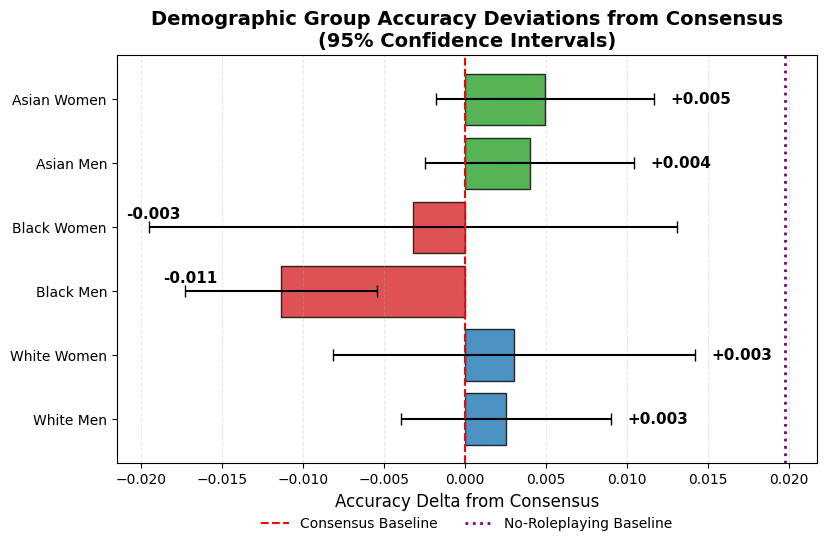

In [21]:
from analysis_0 import *

results = run_full_preliminary_analysis(merged_df)


Running 3-way factorial ANOVA on profile traits...


FACTORIAL ANOVA: ACCURACY
GENDER MAIN EFFECT:
  Male mean: 0.6997
  Female mean: 0.7024
  Difference: 0.0027
  p-value: 0.4023 
  Cohen's d: 0.321

ETHNICITY MAIN EFFECT:
  White mean: 0.7034
  Black mean: 0.6950
  Asian mean: 0.7048
  F-statistic: 4.875
  p-value: 0.0156 ***

COGNITIVE STYLE MAIN EFFECT:
  Expansive mean: 0.7030
  Literal mean: 0.7020
  High_Harm mean: 0.7017
  Low_Harm mean: 0.7027
  Balanced mean: 0.6960
  F-statistic: 0.649
  p-value: 0.6329 

INTERACTION EFFECTS:
  Male White: 0.7032
  Male Black: 0.6916
  Male Asian: 0.7044
  Female White: 0.7036
  Female Black: 0.6984
  Female Asian: 0.7052

FACTORIAL ANOVA: RESCUE_RATE
GENDER MAIN EFFECT:
  Male mean: 0.0440
  Female mean: 0.0442
  Difference: 0.0002
  p-value: 0.9800 
  Cohen's d: 0.010

ETHNICITY MAIN EFFECT:
  White mean: 0.0635
  Black mean: 0.0293
  Asian mean: 0.0394
  F-statistic: 8.852
  p-value: 0.0011 ***

COGNITIVE STYLE MAIN EFFECT:
  Expansive m

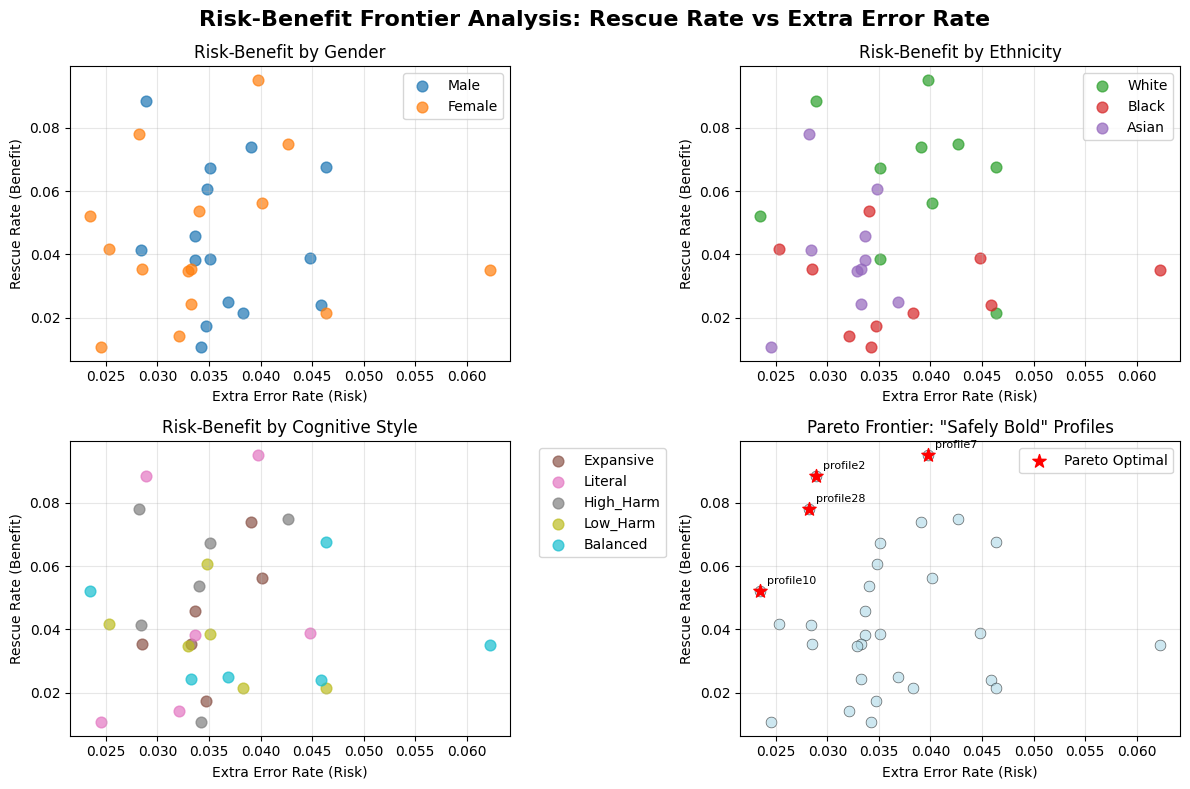


PARETO FRONTIER ANALYSIS

Pareto Optimal Profiles (Safely Bold):
  profile10_passive: Female White Balanced
    Rescue Rate: 0.052, Extra Error Rate: 0.023
  profile28_passive: Female Asian High_Harm
    Rescue Rate: 0.078, Extra Error Rate: 0.028
  profile2_passive: Male White Literal
    Rescue Rate: 0.088, Extra Error Rate: 0.029
  profile7_passive: Female White Literal
    Rescue Rate: 0.095, Extra Error Rate: 0.040

Risk-Benefit Statistics:
  Average rescue rate: 0.044
  Average extra error rate: 0.036
  Best rescue rate: 0.095
  Lowest extra error rate: 0.023

Profile Archetypes:
  Safest Profile: profile10_passive (Female White Balanced)
    Extra Error Rate: 0.023
  Most Beneficial Profile: profile7_passive (Female White Literal)
    Rescue Rate: 0.095

Running effect size calculations for key findings...

CALCULATING ANOVA-BASED EFFECT SIZES

MAIN EFFECTS FROM ANOVA
----------------------------------------

INTERACTION EFFECTS
----------------------------------------

COMPREH

In [13]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df)

## Analysis of Few-shots role playing

In [14]:
from analysis_tools import (
    load_and_merge_profiles
    )
merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_system/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd
)

=== Found 30 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'original_dataset', 'profile1_passive', 'profile2_passive', 'profile3_passive', 'profile4_passive', 'profile5_passive', 'profile6_passive', 'profile7_passive', 'profile8_passive', 'profile9_passive', 'profile10_passive', 'profile11_passive', 'profile12_passive', 'profile13_passive', 'profile14_passive', 'profile15_passive', 'profile16_passive', 'profile17_passive', 'profile18_passive', 'profile19_passive', 'profile20_passive', 'profile21_passive', 'profile22_passive', 'profile23_passive', 'profile24_passive', 'profile25_passive', 'profile26_passive', 'profile27_passive', 'profile28_passive', 'profile29_passive', 'profile30_passive']




=== DEMOGRAPHIC ACCURACY DIFFERENCES ===

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 35
Significant Differences Found: 3
Statistical Significance Rate: 8.6%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_black_women_vs_asian_women Effect Size: -1.665 (Large)
 2. intersectional_black_men_vs_asian_women Effect Size: -1.251 (Large)
 3. intersectional_white_men_vs_asian_women Effect Size: -1.179 (Large)
 4. black_vs_asian                      Effect Size: -1.047 (Large)
 5. cognitive_high_harm_sensitivity_vs_low_harm_sensitivity Effect Size:  1.006 (Large)

GROUP PERFORMANCE RANKING
----------------------------------------
Rank  Group          Accuracy    Std Dev   N Profiles
--------------------------------------------------
1     asian          0.709       0.007     10
2     women          0.707       0.008     15
3     white          0.706       0.00

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)



PERSONA SIMILARITY & CLUSTERING ANALYSIS

SUMMARY:
  • Total personas analyzed: 30
  • Optimal number of clusters: 8
  • Clustering quality (silhouette): 0.120
  • Average cluster size: 3.8

CLUSTER COMPOSITION:
------------------------------------------------------------

CLUSTER_1 (6 personas):
  • Dominant demographic: black_men
  • Internal agreement: 0.970
  • Average accuracy: 0.704
  • Centroid profile: profile1_passive
  • Demographic breakdown: {'white_men': 1, 'white_women': 1, 'black_men': 2, 'asian_men': 2}

CLUSTER_2 (3 personas):
  • Dominant demographic: asian_women
  • Internal agreement: 0.968
  • Average accuracy: 0.715
  • Centroid profile: profile28_passive
  • Demographic breakdown: {'asian_men': 1, 'asian_women': 2}

CLUSTER_3 (3 personas):
  • Dominant demographic: white_men
  • Internal agreement: 0.972
  • Average accuracy: 0.707
  • Centroid profile: profile3_passive
  • Demographic breakdown: {'white_men': 1, 'white_women': 1, 'black_women': 1}

CLUSTER_4 (2

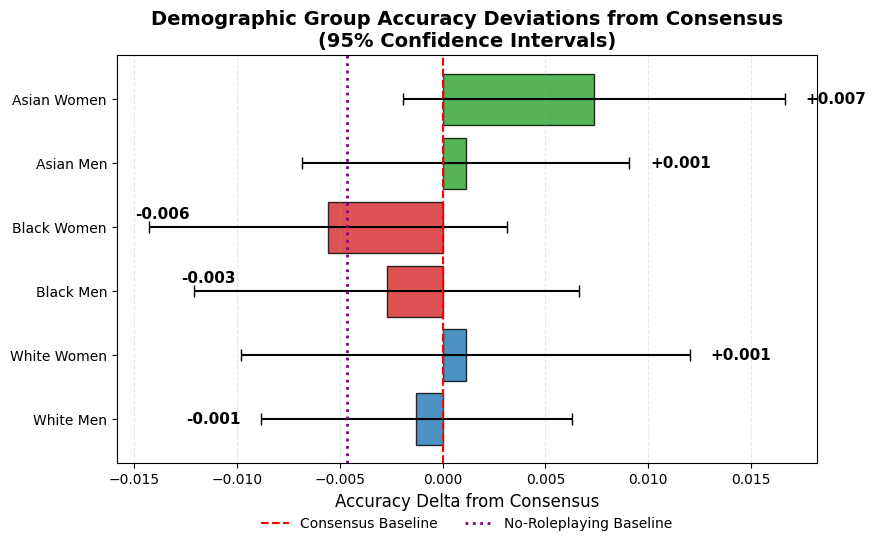

In [15]:
from analysis_0 import *

results = run_full_preliminary_analysis(merged_df)


Running 3-way factorial ANOVA on profile traits...


FACTORIAL ANOVA: ACCURACY
GENDER MAIN EFFECT:
  Male mean: 0.7051
  Female mean: 0.7067
  Difference: 0.0016
  p-value: 0.5654 
  Cohen's d: 0.220

ETHNICITY MAIN EFFECT:
  White mean: 0.7058
  Black mean: 0.7024
  Asian mean: 0.7094
  F-statistic: 2.428
  p-value: 0.1072 

COGNITIVE STYLE MAIN EFFECT:
  Expansive mean: 0.7060
  Literal mean: 0.7040
  High_Harm mean: 0.7093
  Low_Harm mean: 0.7030
  Balanced mean: 0.7070
  F-statistic: 0.644
  p-value: 0.6363 

INTERACTION EFFECTS:
  Male White: 0.7048
  Male Black: 0.7036
  Male Asian: 0.7068
  Female White: 0.7068
  Female Black: 0.7012
  Female Asian: 0.7120

FACTORIAL ANOVA: RESCUE_RATE
GENDER MAIN EFFECT:
  Male mean: 0.0544
  Female mean: 0.0570
  Difference: 0.0026
  p-value: 0.6808 
  Cohen's d: 0.157

ETHNICITY MAIN EFFECT:
  White mean: 0.0586
  Black mean: 0.0495
  Asian mean: 0.0591
  F-statistic: 1.004
  p-value: 0.3798 

COGNITIVE STYLE MAIN EFFECT:
  Expansive mean: 0

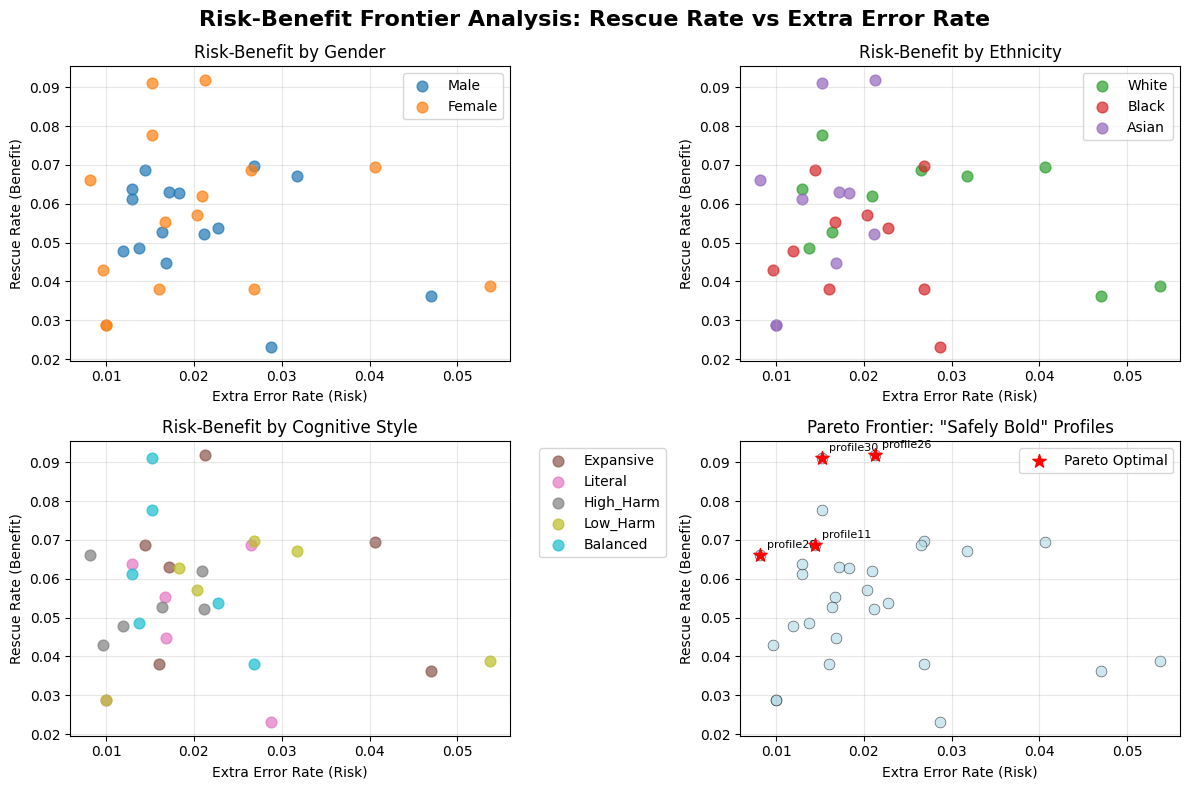


PARETO FRONTIER ANALYSIS

Pareto Optimal Profiles (Safely Bold):
  profile11_passive: Male Black Expansive
    Rescue Rate: 0.069, Extra Error Rate: 0.014
  profile26_passive: Female Asian Expansive
    Rescue Rate: 0.092, Extra Error Rate: 0.021
  profile28_passive: Female Asian High_Harm
    Rescue Rate: 0.066, Extra Error Rate: 0.008
  profile30_passive: Female Asian Balanced
    Rescue Rate: 0.091, Extra Error Rate: 0.015

Risk-Benefit Statistics:
  Average rescue rate: 0.056
  Average extra error rate: 0.021
  Best rescue rate: 0.092
  Lowest extra error rate: 0.008

Profile Archetypes:
  Safest Profile: profile28_passive (Female Asian High_Harm)
    Extra Error Rate: 0.008
  Most Beneficial Profile: profile26_passive (Female Asian Expansive)
    Rescue Rate: 0.092

Running effect size calculations for key findings...

CALCULATING ANOVA-BASED EFFECT SIZES

MAIN EFFECTS FROM ANOVA
----------------------------------------

INTERACTION EFFECTS
---------------------------------------

In [16]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df)

## Manipulation detection

In [17]:
merged_manipulation = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_manipulation_few_shot_prompt_short_3examples.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_core/*/results_manipulation_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mentalmanip,
    extra_cols=["technique", "vulnerability"]
)
merged_manipulation["task"] = "manipulation"

report = evaluate_role_playing_effects(merged_manipulation)
print("\n\n")
print_report(report)

plot_accuracy_deltas_with_ci(merged_manipulation)
#plot_confusion_matrix(merged["true_label"], merged["base_pred"], title="Confusion Matrix - Baseline")
#plot_confusion_matrix(merged["true_label"], merged["profile3_passive"], title="Confusion Matrix - profile3_passive")
#plot_deltas_per_category(merged, category_col="technique")
#plot_deltas_per_category(merged, category_col="vulnerability")

#summary_df = compute_classification_reports(merged)

=== Found 12 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'technique', 'vulnerability', 'profile1_passive', 'profile1_active', 'profile2_passive', 'profile2_active', 'profile3_passive', 'profile3_active', 'profile4_active', 'profile4_passive', 'profile5_active', 'profile5_passive', 'profile6_active', 'profile6_passive']


NameError: name 'evaluate_role_playing_effects' is not defined